The purpose of this notebook is to provide an illustration of the core functionalities of the git repository.

For this purpose we have provide data in the /notebooks/illustration_data folder to allow the user to generate synthetic examples. We provide more detail subsequently.

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from vibes.interference_models.pca import pca, loo_pca
from vibes.absorbance_estimators.vibes import VibeSpec
from vibes.inference.bootstrap import pca_bootstrap, compute_lod

In [2]:
#load data needed to generate synthetic examples
wavenumbers = np.load("./illustration_data/wavenumbers.npy")
SO4_profile = np.load("./illustration_data/SO4.npy")
mu_true = np.load("./illustration_data/mu_true.npy")
W_true = np.load("./illustration_data/W_true.npy")

To generate synthetic data we used the ammonium sulfate profile from Earle et al. (2006) limited to the above wavenumbers and scaled to have 
maximum value equal to 1. We subsequently refer to this profile as $\boldsymbol{\nu}$. Next we interpolated the pfte blank filters used in the 
paper to these wavenumbers and extract the first five scaled right singular vectors obtained from a SVD after detrending. We refer to the
mean and scaled right singular vectors as $\boldsymbol{\mu}^{*}$ and $\mathsf{W}^{*}$ respectively. 

To generate a synthetic interference example we use

\begin{equation} \notag 
\boldsymbol{z} = \boldsymbol{\mu}^{*} + \mathsf{W}^{*} \boldsymbol{x},
\end{equation}

where $\boldsymbol{x}$ consists of five independent standard Gaussain realizations. Below we generate 50 such examples.

In [109]:
rng = np.random.default_rng(seed=0)
X = rng.standard_normal([50,W_true.shape[1]])
Z = mu_true + X @ W_true.T

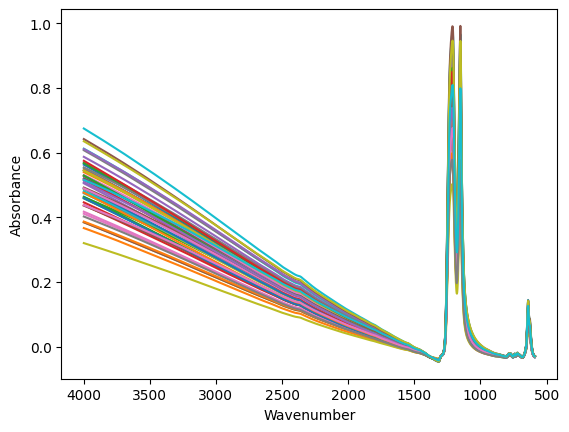

In [111]:
for i in range(Z.shape[0]):
    plt.plot(wavenumbers, Z[i, :])

plt.ylabel("Absorbance")
plt.xlabel("Wavenumber")
plt.gca().invert_xaxis()

To generate a synthetic loaded filter we use

\begin{equation} \notag 
\boldsymbol{y} = \boldsymbol{\mu}^{*} + \mathsf{W}^{*} \boldsymbol{x} + f \boldsymbol{\nu},
\end{equation}

where $\boldsymbol{x}$ again consists of five independent standard Gaussain realizations, but independent of those that were used for 
the interference examples.


In [102]:
f = 0.05
y = mu_true + W_true @ rng.standard_normal(W_true.shape[1]) + f*SO4_profile

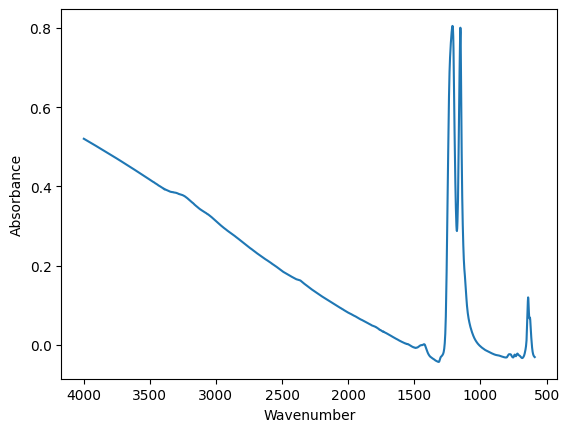

In [ ]:
plt.plot(wavenumbers, y)
plt.ylabel("Absorbance")
plt.xlabel("Wavenumber")
plt.gca().invert_xaxis()

Next we estimate the number of PCA components using leave-one-out cross validation under the one-standard-error rule.

In [113]:
_, chat_ose ,_ = loo_pca(Z,detrend=True)
mu, _, _, W = pca(Z)
W = W[:,:chat_ose]

print(f"Number of components seleceted is {chat_ose}.")

Number of components seleceted is 6.


We initialize a vibes instance, estimate the hyper-parameters and compute the corresponding map assignment.

In [114]:
mod = VibeSpec(c = chat_ose ,loss = "PB")
mod.fit(y,mu,W)
z,x = mod.map_solver.solve(y,mu,W)

To estimate the limit of detection (lod) we draw bootstrap replicates of the estimated interference by bootstrapping from the interference examples keeping
the calibrated hyper-parameters fixed.

In [115]:
boot_x, boot_z = pca_bootstrap(y, Z, mod.tau, mod.sigma_hat, mod.c, B=100, loss="PB",verbose=True)
xi,stdev = compute_lod(boot_z, z, alpha=0.01)
lod = xi*stdev

100%|██████████| 100/100 [00:06<00:00, 16.08it/s]


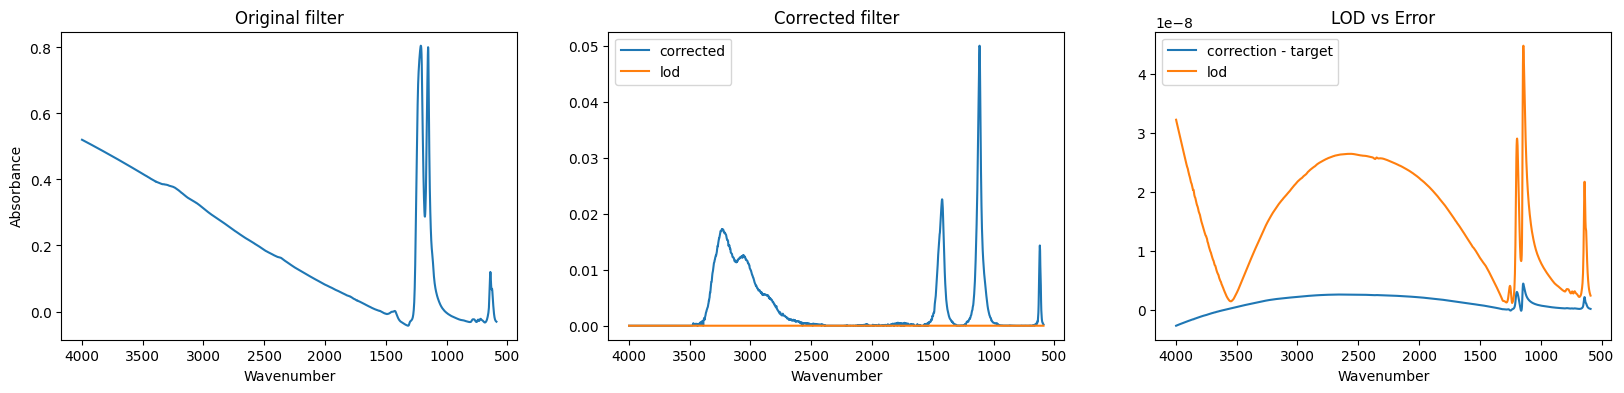

In [137]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 4),
)

axes[0].plot(wavenumbers, y)
axes[0].set_ylabel("Absorbance")
axes[0].set_xlabel("Wavenumber")
axes[0].set_title("Original filter")
axes[0].invert_xaxis()

axes[1].plot(wavenumbers, y - z,label="corrected")
axes[1].plot(wavenumbers, lod,label="lod")
axes[1].set_xlabel("Wavenumber")
axes[1].legend()
axes[1].set_title("Corrected filter")
axes[1].invert_xaxis()

axes[2].plot(wavenumbers, y - z - f*SO4_profile, label="correction - target")
axes[2].plot(wavenumbers, lod, label="lod")
axes[2].set_xlabel("Wavenumber")
axes[2].set_title("LOD vs Error")
axes[2].legend()
axes[2].invert_xaxis()

References:

M. E. Earle, R. G. Pancescu, B. Cosic, A. Y. Zasetsky, and J. J. Sloan. Temperature Dependent Complex Indices of Refraction for Crystalline (NH4)2so4. The Journal of
Physical Chemistry A, 110(48):13022–13028, December 2006.